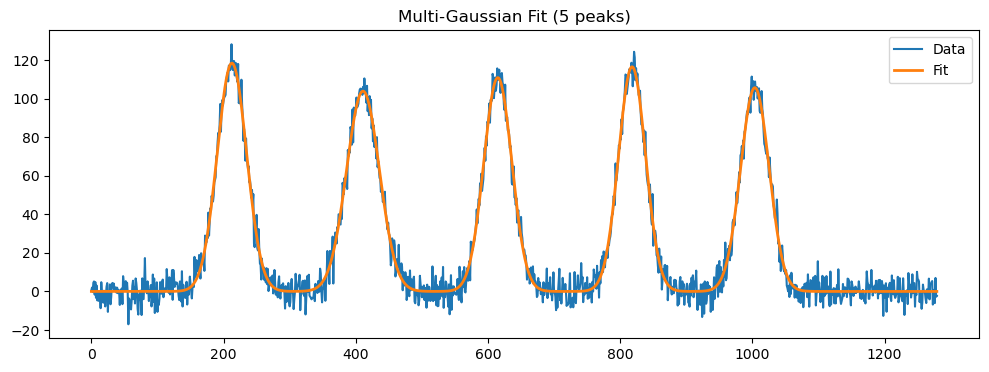

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# --- Generate synthetic test data ---
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2))

def multi_gaussian(x, *params):
    y = np.zeros_like(x, dtype=float)
    for i in range(0, len(params), 3):
        A = params[i]
        mu = params[i + 1]
        sigma = params[i + 2]
        y += A * np.exp(-((x - mu)**2) / (2 * sigma**2))
    return y

# Simulate 5 peaks across 1280 points
x = np.arange(1280)
true_params = []
for i in range(5):
    A = 100 + np.random.rand() * 20
    mu = 200 + i * 200 + np.random.rand() * 20
    sigma = 20 + np.random.rand() * 5
    true_params += [A, mu, sigma]

y = multi_gaussian(x, *true_params) + np.random.normal(0, 5, size=x.shape)

# --- Guess initial parameters ---
def guess_initials(profile, num_peaks=5):
    peaks, _ = find_peaks(profile, distance=150)
    top_peaks = peaks[np.argsort(profile[peaks])][-num_peaks:]  # strongest peaks
    top_peaks = np.sort(top_peaks)

    init = []
    for p in top_peaks:
        A = float(profile[p])
        mu = float(p)
        sigma = 30.0
        init += [A, mu, sigma]
    return init

init_guess = guess_initials(y, num_peaks=5)

# --- Fit the profile ---
popt, _ = curve_fit(multi_gaussian, x, y, p0=init_guess)

# --- Plot ---
plt.figure(figsize=(12, 4))
plt.plot(x, y, label="Data")
plt.plot(x, multi_gaussian(x, *popt), label="Fit", lw=2)
plt.legend()
plt.title("Multi-Gaussian Fit (5 peaks)")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tifffile import imread  # pip install tifffile

# --- Load image (change path to your .tif file)
image_path = "5x5tweezers.tif"
img = imread(image_path).astype(float)

# --- Define 1D Gaussian function
def gaussian(x, A, mu, sigma, offset):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

# --- Collapse image along y and x to get intensity profiles
x_profile = np.sum(img, axis=0)
y_profile = np.sum(img, axis=1)

x = np.arange(len(x_profile))
y = np.arange(len(y_profile))

# --- Guess initial parameters
def guess_init(profile, axis):
    A = np.max(profile) - np.min(profile)
    mu = np.sum(axis * profile) / np.sum(profile)
    sigma = np.sqrt(np.sum(profile * (axis - mu)**2) / np.sum(profile))
    offset = np.min(profile)
    return A, mu, sigma, offset

init_x = guess_init(x_profile, x)
init_y = guess_init(y_profile, y)

# --- Fit the Gaussian envelopes
popt_x, _ = curve_fit(gaussian, x, x_profile, p0=init_x)
popt_y, _ = curve_fit(gaussian, y, y_profile, p0=init_y)

# --- Plot results
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(x, x_profile, label="X profile")
axs[0].plot(x, gaussian(x, *popt_x), 'k--', label="Gaussian fit")
axs[0].set_title("X Profile with Gaussian Envelope")
axs[0].legend()

axs[1].plot(y, y_profile, label="Y profile")
axs[1].plot(y, gaussian(y, *popt_y), 'k--', label="Gaussian fit")
axs[1].set_title("Y Profile with Gaussian Envelope")
axs[1].legend()

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\AndreaFantini\\labscript-suite\\userlib\\user_devices\\SpectrumAWG\\5x5tweezers.tif'